<a href="https://colab.research.google.com/github/BenjaminIH/LA_Crime_project/blob/main/School_hospital_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/california_housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
# We posit that houses close to either a school or a hospital are more expensive.

### WARNING - wrong coordinates - we are going to swap latitudes between school and hospital! :'(
# School coordinates (-118, 37)
# Hospital coordinates (-122, 34)
# We consider a house (neighborhood) to be close to a school or hospital if the distance is lower than 0.50.

# Hint:

# Write a function to calculate euclidean distance from each house (neighborhood) to the school and to the hospital.
# Divide your dataset into houses close and far from either a hospital or school.
# Choose the propper test and, with 5% significance, comment your findings.

In [ ]:
def distance_school(row):
  s_long, s_lat = (-118, 34)
  distance = (row["longitude"] - s_long)**2 + (row["latitude"] - s_lat)**2
  return np.sqrt(distance)


def distance_hospital(row):
  h_long, h_lat = (-122, 37)
  distance = (row["longitude"] - h_long)**2 + (row["latitude"] - h_lat)**2
  return np.sqrt(distance)

In [ ]:
df["distance_to_school"] = df.apply(distance_school, axis=1)

df["distance_to_hospital"] = df.apply(distance_hospital, axis=1)


df.head(20)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_school,distance_to_hospital,is_close
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,3.694888,8.187319,False
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,3.552591,7.966235,False
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,3.453940,8.143077,False
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,3.448840,8.154416,False
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,3.456848,8.183508,False
5,-114.58,33.63,29.0,1387.0,236.0,671.0,239.0,3.3438,74000.0,3.439956,8.149436,False
6,-114.58,33.61,25.0,2907.0,680.0,1841.0,633.0,2.6768,82400.0,3.442165,8.157726,False
7,-114.59,34.83,41.0,812.0,168.0,375.0,158.0,1.7083,48500.0,3.509558,7.721205,False
8,-114.59,33.61,34.0,4789.0,1175.0,3134.0,1056.0,2.1782,58400.0,3.432230,8.148632,False
9,-114.60,34.83,46.0,1497.0,309.0,787.0,271.0,2.1908,48100.0,3.499843,7.711608,False


In [ ]:
def is_close(row, threshold = 0.50):
  if (row["distance_to_school"] < threshold) or (row["distance_to_hospital"] < threshold):
    return True
  else:
    return False

df["is_close"] = df.apply(is_close, axis = 1)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_school,distance_to_hospital,is_close
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,3.694888,8.187319,False
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,3.552591,7.966235,False
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,3.453940,8.143077,False
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,3.448840,8.154416,False
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,3.456848,8.183508,False


In [ ]:
df[df["is_close"]==False]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_school,distance_to_hospital,is_close
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,3.694888,8.187319,False
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,3.552591,7.966235,False
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,3.453940,8.143077,False
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,3.448840,8.154416,False
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,3.456848,8.183508,False
...,...,...,...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,9.082070,4.233675,False
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0,9.168915,4.332320,False
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0,10.057614,5.358694,False
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0,10.026465,5.322593,False


In [ ]:
df[df["distance_to_hospital"]<0.50]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_school,distance_to_hospital,is_close


In [ ]:
# School coordinates (-118, 37)
# Hospital coordinates (-122, 34)

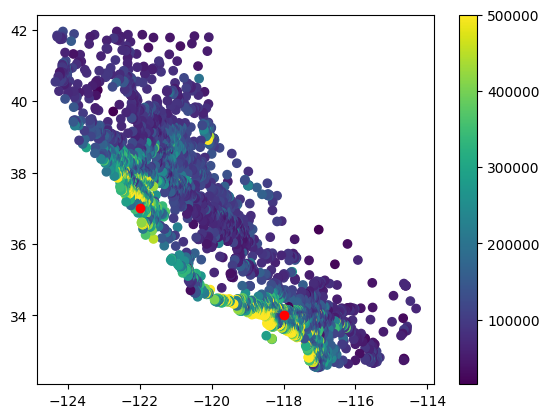

In [ ]:
plt.scatter(df["longitude"], df["latitude"], c = df["median_house_value"])
plt.plot(-118, 34, "ro")
plt.plot(-122, 37, "ro")
plt.colorbar()
plt.show()

In [ ]:
##
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_school,distance_to_hospital,is_close
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,3.694888,8.187319,False
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,3.552591,7.966235,False
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,3.453940,8.143077,False
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,3.448840,8.154416,False
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,3.456848,8.183508,False


In [ ]:
# IND TEST or REL TEST

import scipy.stats as st


df_close = df[df["is_close"]==True]["median_house_value"]
df_far = df[df["is_close"]==False]["median_house_value"]


In [ ]:
#H0: mu house_value Far = mu house_value Close
#H1: mu house_value Far != mu house_value Close

#significance level - 5%

st.ttest_ind(df_far, df_close, equal_var=False)

TtestResult(statistic=-37.992330214201516, pvalue=3.0064957768592614e-301, df=14571.229910954282)

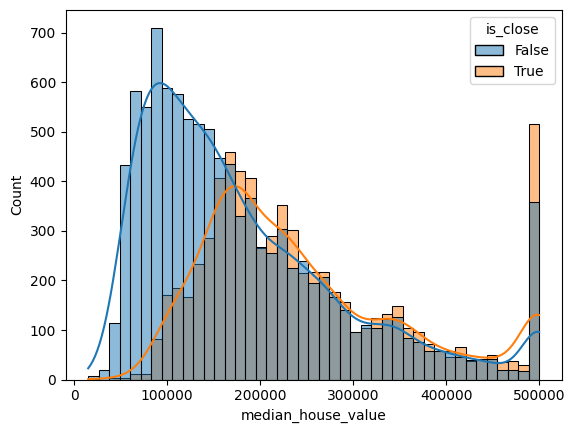

In [ ]:
#With a 5% significance, we can reject the null hypothesis, therefore we gather enough evidence to claim that average house_value is indeed impacted
#by distance to a school/hospital.

import seaborn as sns


sns.histplot(data=df, x="median_house_value", hue="is_close", kde = True)
plt.show()

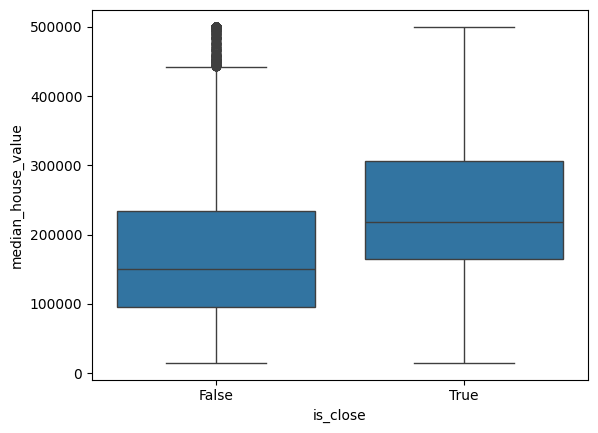

In [ ]:
sns.boxplot(data = df, x = "is_close", y="median_house_value")
plt.show()

In [ ]:
#we might believe that houses close to a school or hospital are more expensive

#H0: mu house_value Far >= mu house_value Close
#H1: mu house_value Far < mu house_value Close

#significance level - 5%

st.ttest_ind(df_far, df_close, equal_var=False, alternative = "less")

TtestResult(statistic=-37.992330214201516, pvalue=1.5032478884296307e-301, df=14571.229910954282)